# Neural Network Implementation from Scratch

**Course:** Generative AI Lab  
**Department:** CSE (AIML)  
**Class:** T.Y. Tech  
**Assignment:** Neural Network Implementation from Scratch

> This notebook implements a feedforward neural network using **NumPy from scratch**. No TensorFlow, Keras, PyTorch, or other deep-learning framework is used.

## Objective
Implement the core components of a neural network:
- Data preparation
- Weight and bias initialization
- Forward propagation
- Softmax activation
- Cross-entropy loss
- Backpropagation
- Gradient descent optimization
- Model evaluation and visualization


## 1. Student Information

- **Name:** Bhushan Yogesh Bhamare
- **PRN Number:** *202401110078*
- **Date of Submission:** 15 August 2026
- **GitHub Repository:** *https://github.com/BhushanBhamare2005/neural-network-from-scratch*


## 2. Problem Definition

### Dataset
The **Iris dataset** contains 150 samples of iris flowers. Each sample has four numerical features:
1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

There are three classes:
- Setosa
- Versicolor
- Virginica

### Task
This is a **multi-class classification** problem. The neural network predicts one of the three flower species from the four input features.

The dataset is loaded through `sklearn.datasets` only as a convenient data source; the neural network, loss, gradients, optimizer, and prediction logic are implemented manually with NumPy.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy version:", np.__version__)
print("Libraries loaded successfully.")


NumPy version: 2.3.5
Libraries loaded successfully.


## 3. Load and Explore the Dataset

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data.astype(np.float64)
y = iris.target.astype(int)

feature_names = iris.feature_names
class_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["class"] = [class_names[i] for i in y]

print("Dataset shape:", X.shape)
print("Number of classes:", len(class_names))
display(df.head())

print("\nClass distribution:")
print(df["class"].value_counts().sort_index())


Dataset shape: (150, 4)
Number of classes: 3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Class distribution:
class
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Train-Test Split and Standardization

The data is split into **80% training** and **20% testing** samples.

Feature standardization is performed using only the training-set mean and standard deviation. This avoids data leakage from the test set.


In [3]:
# Shuffle indices reproducibly
indices = np.random.permutation(len(X))
split = int(0.80 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Standardize using training statistics only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 120
Testing samples : 30


## 5. One-Hot Encoding

For three output classes, the target labels are represented as one-hot vectors.

Example:

`class 0 -> [1, 0, 0]`

`class 1 -> [0, 1, 0]`

`class 2 -> [0, 0, 1]`


In [4]:
def one_hot(labels, num_classes):
    encoded = np.zeros((len(labels), num_classes))
    encoded[np.arange(len(labels)), labels] = 1
    return encoded

num_classes = len(class_names)
Y_train = one_hot(y_train, num_classes)
Y_test = one_hot(y_test, num_classes)

print("One-hot target shape:", Y_train.shape)
print(Y_train[:5])


One-hot target shape: (120, 3)
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


## 6. Neural Network Architecture

The network used in this assignment is:

**Input layer:** 4 neurons  
↓  
**Hidden layer:** 8 neurons with ReLU activation  
↓  
**Output layer:** 3 neurons with Softmax activation

### Mathematical formulation

Hidden layer:

`Z1 = XW1 + b1`

`A1 = ReLU(Z1)`

Output layer:

`Z2 = A1W2 + b2`

`A2 = Softmax(Z2)`

The output probabilities are compared with the one-hot targets using categorical cross-entropy.


In [5]:
# Network dimensions
input_size = X_train.shape[1]     # 4
hidden_size = 8
output_size = num_classes         # 3

# He-style initialization for ReLU hidden layer
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

# Small random initialization for output layer
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)


W1 shape: (4, 8)
b1 shape: (1, 8)
W2 shape: (8, 3)
b2 shape: (1, 3)


## 7. Activation Functions

### ReLU
`ReLU(x) = max(0, x)`

Derivative:

`ReLU'(x) = 1 if x > 0, otherwise 0`

### Softmax
Softmax converts output logits into probabilities:

`softmax(z_i) = exp(z_i) / sum(exp(z_j))`

A numerically stable implementation subtracts the maximum logit before exponentiation.


In [6]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Quick function checks
test_values = np.array([[-2.0, 0.0, 2.0]])
print("ReLU:", relu(test_values))
print("Softmax:", softmax(test_values))
print("Softmax row sum:", softmax(test_values).sum(axis=1))


ReLU: [[0. 0. 2.]]
Softmax: [[0.01587624 0.11731043 0.86681333]]
Softmax row sum: [1.]


## 8. Forward Pass

The forward pass calculates the hidden-layer activation and final class probabilities.

Steps:
1. Multiply input by the first weight matrix.
2. Add the first bias.
3. Apply ReLU.
4. Multiply hidden activations by the second weight matrix.
5. Add the second bias.
6. Apply Softmax.


In [7]:
def forward_pass(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

Z1, A1, Z2, A2 = forward_pass(X_train, W1, b1, W2, b2)

print("Z1:", Z1.shape)
print("A1:", A1.shape)
print("Z2:", Z2.shape)
print("A2:", A2.shape)
print("\nFirst prediction probabilities:", A2[0])
print("Probability sum:", A2[0].sum())


Z1: (120, 8)
A1: (120, 8)
Z2: (120, 3)
A2: (120, 3)

First prediction probabilities: [0.31592516 0.41035352 0.27372131]
Probability sum: 1.0


## 9. Cross-Entropy Loss

For multi-class classification:

`L = -(1/m) * sum(y_true * log(y_pred))`

A small epsilon is added to prevent `log(0)`.


In [8]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-12
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred_clipped), axis=1))

loss = cross_entropy_loss(Y_train, A2)
print("Initial cross-entropy loss:", loss)


Initial cross-entropy loss: 1.628173026514141


## 10. Backpropagation

For Softmax + cross-entropy, the output-layer gradient simplifies to:

`dZ2 = A2 - Y`

Then:

`dW2 = A1.T @ dZ2 / m`

`db2 = sum(dZ2) / m`

The error is propagated to the hidden layer:

`dA1 = dZ2 @ W2.T`

`dZ1 = dA1 * ReLU'(Z1)`

Then:

`dW1 = X.T @ dZ1 / m`

`db1 = sum(dZ1) / m`


In [9]:
def backward_pass(X, Y, Z1, A1, A2, W2):
    m = X.shape[0]

    dZ2 = A2 - Y
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

dW1, db1, dW2, db2 = backward_pass(X_train, Y_train, Z1, A1, A2, W2)

print("dW1:", dW1.shape)
print("db1:", db1.shape)
print("dW2:", dW2.shape)
print("db2:", db2.shape)


dW1: (4, 8)
db1: (1, 8)
dW2: (8, 3)
db2: (1, 3)


## 11. Gradient Descent Training

Weights are updated using:

`W = W - learning_rate * gradient`

The network is trained for multiple epochs. Training loss and training accuracy are recorded to visualize learning.


In [10]:
def predict_proba(X, W1, b1, W2, b2):
    _, _, _, probs = forward_pass(X, W1, b1, W2, b2)
    return probs

def predict(X, W1, b1, W2, b2):
    return np.argmax(predict_proba(X, W1, b1, W2, b2), axis=1)

def accuracy_score_np(y_true, y_pred):
    return np.mean(y_true == y_pred)

learning_rate = 0.05
epochs = 3000

loss_history = []
accuracy_history = []

for epoch in range(epochs):
    # Forward pass
    Z1, A1, Z2, A2 = forward_pass(X_train, W1, b1, W2, b2)

    # Loss
    loss = cross_entropy_loss(Y_train, A2)
    loss_history.append(loss)

    # Backpropagation
    dW1, db1, dW2, db2 = backward_pass(
        X_train, Y_train, Z1, A1, A2, W2
    )

    # Gradient descent update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Training accuracy
    train_pred = np.argmax(A2, axis=1)
    accuracy_history.append(accuracy_score_np(y_train, train_pred))

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch + 1:4d}/{epochs} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy_history[-1] * 100:.2f}%"
        )


Epoch  500/3000 | Loss: 0.1291 | Accuracy: 95.00%
Epoch 1000/3000 | Loss: 0.0780 | Accuracy: 96.67%
Epoch 1500/3000 | Loss: 0.0628 | Accuracy: 97.50%
Epoch 2000/3000 | Loss: 0.0556 | Accuracy: 98.33%


Epoch 2500/3000 | Loss: 0.0515 | Accuracy: 98.33%


Epoch 3000/3000 | Loss: 0.0487 | Accuracy: 98.33%


## 12. Training Visualization

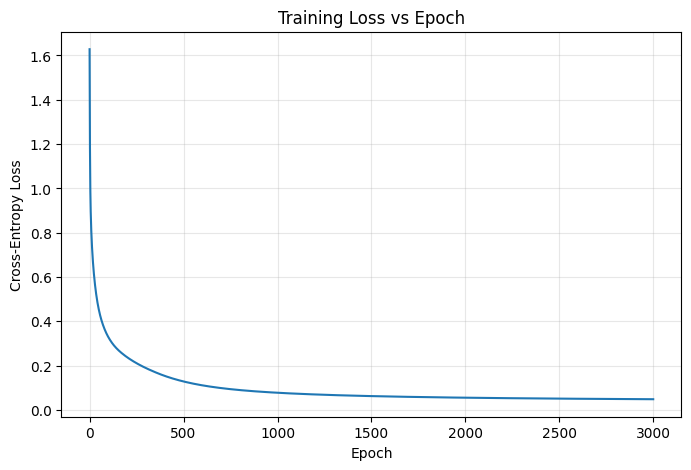

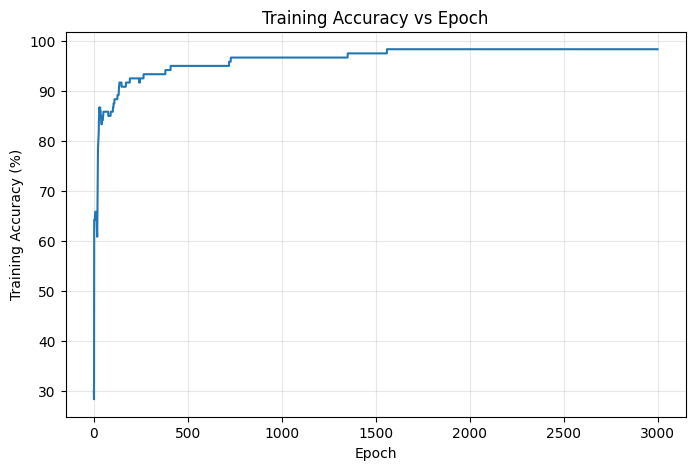

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(np.array(accuracy_history) * 100)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy vs Epoch")
plt.grid(True, alpha=0.3)
plt.show()


## 13. Test Evaluation

The final model is evaluated on the unseen test set. Accuracy is calculated without using a machine-learning model for prediction.


In [12]:
test_probs = predict_proba(X_test, W1, b1, W2, b2)
test_pred = np.argmax(test_probs, axis=1)

test_accuracy = accuracy_score_np(y_test, test_pred)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("\nPredicted classes:", test_pred)
print("Actual classes   :", y_test)


Test Accuracy: 96.67%

Predicted classes: [1 0 1 1 0 1 2 2 0 1 2 2 0 2 0 1 2 2 1 2 1 1 2 2 0 1 1 0 1 2]
Actual classes   : [1 0 1 1 0 1 2 2 0 1 2 2 0 2 0 1 2 2 1 2 1 1 2 2 0 1 2 0 1 2]


## 14. Confusion Matrix

A confusion matrix shows how many samples from each actual class were correctly or incorrectly classified.


,Predicted setosa,Predicted versicolor,Predicted virginica
Actual setosa,7,0,0
Actual versicolor,0,11,0
Actual virginica,0,1,11


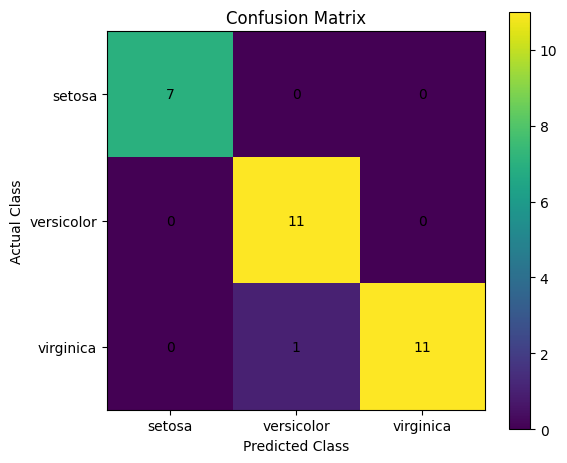

In [13]:
confusion = np.zeros((num_classes, num_classes), dtype=int)

for actual, predicted in zip(y_test, test_pred):
    confusion[actual, predicted] += 1

confusion_df = pd.DataFrame(
    confusion,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

display(confusion_df)

plt.figure(figsize=(6, 5))
plt.imshow(confusion, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(num_classes), class_names)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, confusion[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 15. Sample Predictions

The table below compares actual labels, predicted labels, and the model's confidence for the predicted class.


In [14]:
sample = pd.DataFrame({
    "Actual": [class_names[i] for i in y_test],
    "Predicted": [class_names[i] for i in test_pred],
    "Confidence": np.max(test_probs, axis=1)
})

display(sample.head(15))


,Actual,Predicted,Confidence
0,versicolor,versicolor,0.990217
1,setosa,setosa,0.637505
2,versicolor,versicolor,0.997645
3,versicolor,versicolor,0.997991
4,setosa,setosa,0.999969
5,versicolor,versicolor,0.995048
6,virginica,virginica,0.998113
7,virginica,virginica,0.996641
8,setosa,setosa,0.999982
9,versicolor,versicolor,0.998654


## 16. Results and Discussion

### Result
The neural network successfully learned the mapping between the four Iris features and the three flower classes using only NumPy-based neural-network operations.

### Key observations
- The training loss decreases as gradient descent updates the parameters.
- Training accuracy improves as the model learns useful decision boundaries.
- Test accuracy demonstrates the model's ability to generalize to unseen samples.
- ReLU provides a nonlinear hidden representation.
- Softmax converts the final logits into class probabilities.
- Cross-entropy provides a suitable loss for multi-class classification.

### Learning Outcome
This implementation demonstrates the complete neural-network pipeline without relying on high-level deep-learning frameworks:
**data → forward pass → loss → backpropagation → gradient descent → prediction → evaluation**.


## 17. Limitations and Future Improvements

1. The network has only one hidden layer and a small number of neurons.
2. The optimizer is basic batch gradient descent.
3. No dropout, batch normalization, or learning-rate scheduling is used.
4. The Iris dataset is small, so performance should not be generalized to large datasets.
5. Future work can implement mini-batch SGD, Adam, L2 regularization, early stopping, and additional hidden layers.


## 18. Declaration

I, **Bhushan Yogesh Bhamare**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

**GitHub Repository Link:** *Insert your GitHub repository link here*

**Signature:** Bhushan Yogesh Bhamare


## 19. Submission Checklist

- [x] Python Notebook with neural network implementation
- [x] Dataset and dataset description
- [x] Forward propagation
- [x] Backpropagation
- [x] Cross-entropy loss
- [x] Gradient descent
- [x] Training loss visualization
- [x] Training accuracy visualization
- [x] Test accuracy
- [x] Confusion matrix
- [x] Sample predictions
- [ ] Add PRN number
- [ ] Add batch
- [ ] Add GitHub repository link
- [ ] Execute all cells before final submission
